In [4]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn meteostat

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Étape 1 — Chargement des données
import pandas as pd
import numpy as np

# Dataset UCI - Metro Interstate Traffic Volume
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
df = pd.read_csv(url)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
#Étape 2 — Nettoyage & Feature Engineering
import pandas as pd
import numpy as np
# Conversion de la colonne date
df['date_time'] = pd.to_datetime(df['date_time'])

# Extraction des variables temporelles
df['hour']       = df['date_time'].dt.hour
df['day_of_week']= df['date_time'].dt.day_name()
df['month']      = df['date_time'].dt.month
df['year']       = df['date_time'].dt.year
df['is_weekend'] = df['date_time'].dt.dayofweek >= 5

# Suppression des doublons
df.drop_duplicates(subset='date_time', inplace=True)

# Vérification des valeurs manquantes
df.isnull().sum()

holiday                40522
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
hour                       0
day_of_week                0
month                      0
year                       0
is_weekend                 0
dtype: int64

In [7]:
#Étape 3 — Statistiques descriptives
df[['traffic_volume','temp','rain_1h','snow_1h','clouds_all']].describe()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,40575.000000,40575.000000,40575.000000,40575.000000,40575.000000
mean,3290.650474,281.316763,0.318632,0.000117,44.199162
std,1984.772909,13.816618,48.812640,0.005676,38.683447
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1248.500000,271.840000,0.000000,0.000000,1.000000
50%,3427.000000,282.860000,0.000000,0.000000,40.000000
75%,4952.000000,292.280000,0.000000,0.000000,90.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000


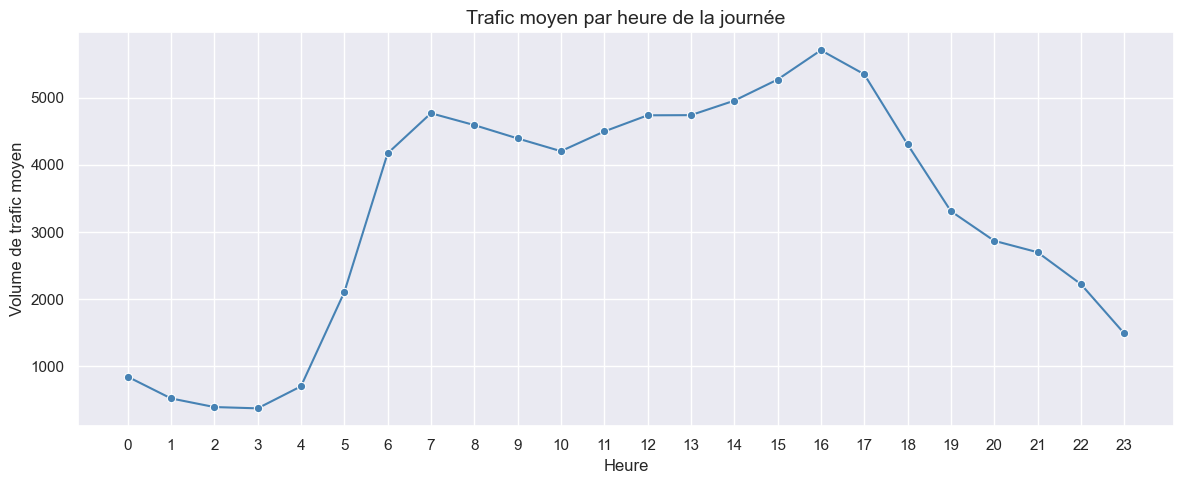

In [4]:
#Étape 4 — Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

hourly = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o', color='steelblue')
plt.title("Trafic moyen par heure de la journée", fontsize=14)
plt.xlabel("Heure")
plt.ylabel("Volume de trafic moyen")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

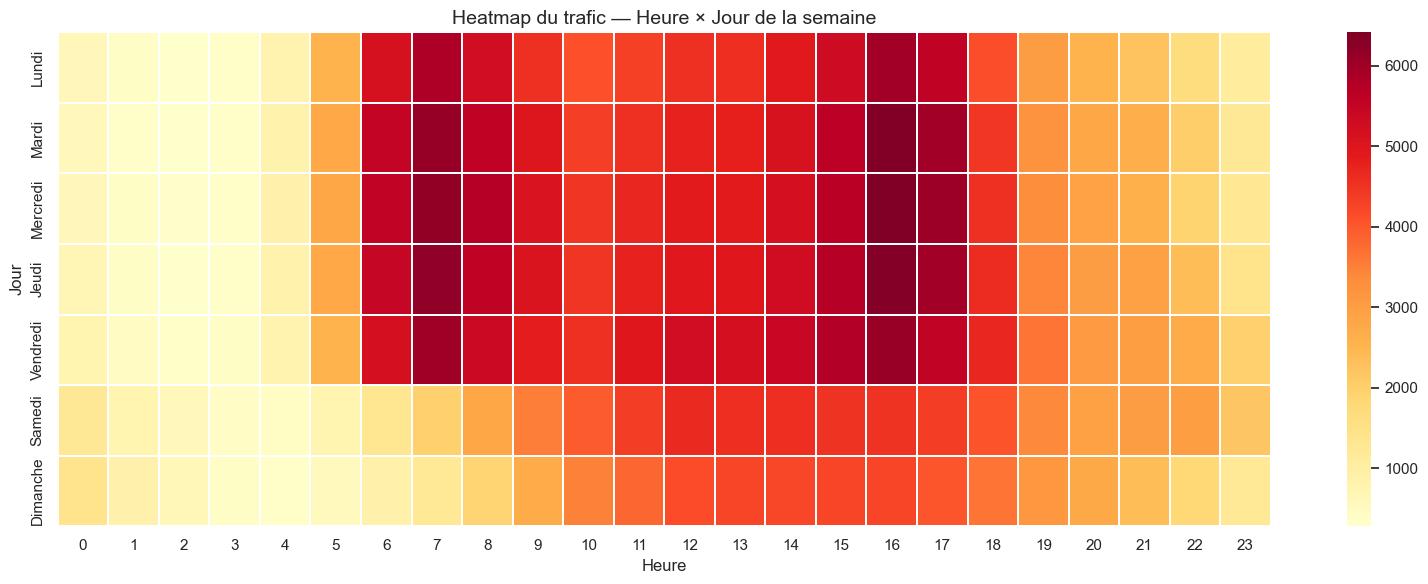

In [7]:
#Heatmap Heure × Jour de la semaine 

pivot = df.pivot_table(
    values='traffic_volume',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(days_order)

# Traduction en français
pivot.index = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
pivot.index.name = 'Jour'
pivot.columns.name = 'Heure'

# Affichage de la heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title("Heatmap du trafic — Heure × Jour de la semaine", fontsize=14)
plt.tight_layout()
plt.show()

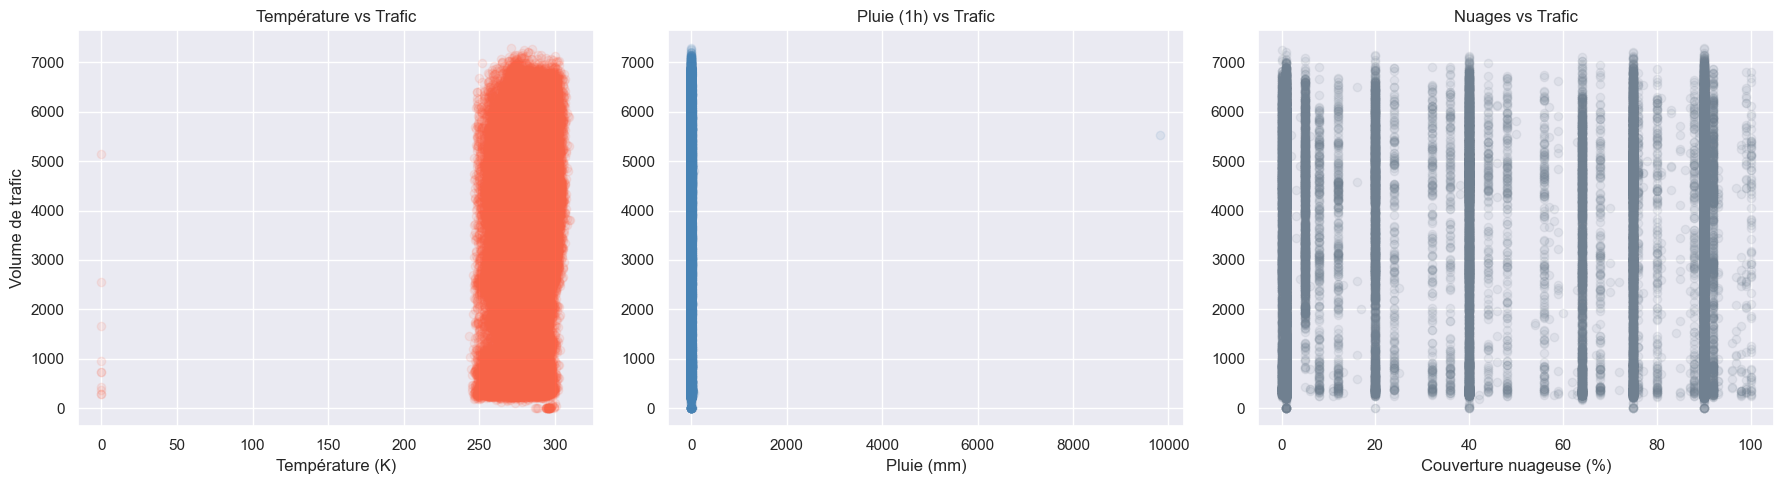

In [10]:
 #Impact de la météo sur le trafic
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Température vs Trafic
axes[0].scatter(df['temp'], df['traffic_volume'], alpha=0.1, color='tomato')
axes[0].set_title("Température vs Trafic")
axes[0].set_xlabel("Température (K)")
axes[0].set_ylabel("Volume de trafic")

# Pluie vs Trafic
axes[1].scatter(df['rain_1h'], df['traffic_volume'], alpha=0.1, color='steelblue')
axes[1].set_title("Pluie (1h) vs Trafic")
axes[1].set_xlabel("Pluie (mm)")

# Couverture nuageuse vs Trafic
axes[2].scatter(df['clouds_all'], df['traffic_volume'], alpha=0.1, color='slategray')
axes[2].set_title("Nuages vs Trafic")
axes[2].set_xlabel("Couverture nuageuse (%)")

plt.tight_layout()
plt.show()

C:\Users\ekamouzou\AppData\Local\Temp\ipykernel_22692\2964512116.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_traffic.values, y=weather_traffic.index, palette='coolwarm')


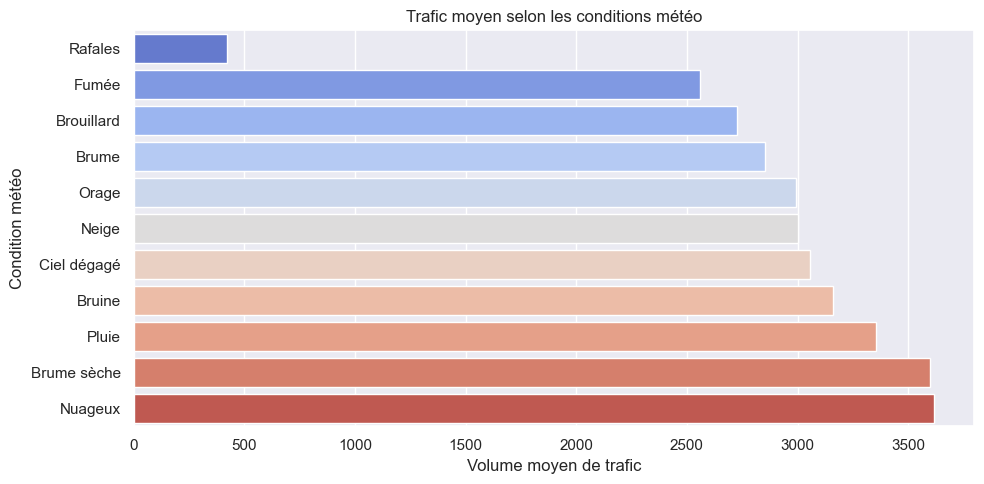

In [8]:
# Trafic moyen par condition météo
# Dictionnaire de traduction des conditions météo
meteo_traduction = {
    'Clear'       : 'Ciel dégagé',
    'Clouds'      : 'Nuageux',
    'Rain'        : 'Pluie',
    'Drizzle'     : 'Bruine',
    'Thunderstorm': 'Orage',
    'Snow'        : 'Neige',
    'Mist'        : 'Brume',
    'Fog'         : 'Brouillard',
    'Haze'        : 'Brume sèche',
    'Smoke'       : 'Fumée',
    'Dust'        : 'Poussière',
    'Sand'        : 'Sable',
    'Squall'      : 'Rafales',
    'Tornado'     : 'Tornade'
}

# Calcul du trafic moyen par condition météo
weather_traffic = df.groupby('weather_main')['traffic_volume'].mean().sort_values()

# Traduction de l'index (les noms des conditions)
weather_traffic.index = weather_traffic.index.map(
    lambda x: meteo_traduction.get(x, x)  # si pas trouvé, garde le nom original
)

# Affichage
plt.figure(figsize=(10, 5))
sns.barplot(x=weather_traffic.values, y=weather_traffic.index, palette='coolwarm')
plt.title("Trafic moyen selon les conditions météo")
plt.xlabel("Volume moyen de trafic")
plt.ylabel("Condition météo")
plt.tight_layout()
plt.show()

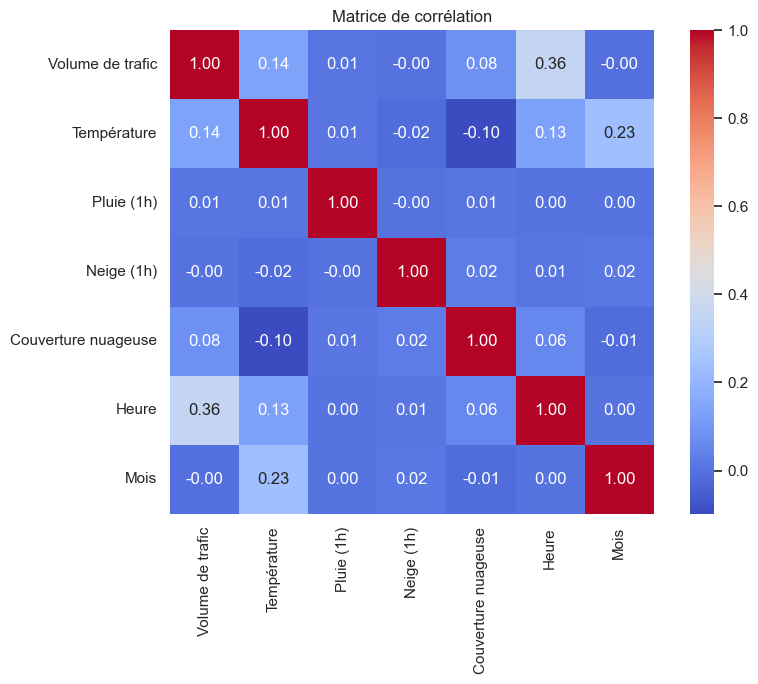

In [9]:
# Dictionnaire de traduction des colonnes
colonnes_traduction = {
    'traffic_volume' : 'Volume de trafic',
    'temp'           : 'Température',
    'rain_1h'        : 'Pluie (1h)',
    'snow_1h'        : 'Neige (1h)',
    'clouds_all'     : 'Couverture nuageuse',
    'hour'           : 'Heure',
    'month'          : 'Mois'
}

# Calcul de la matrice de corrélation
corr_cols = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'month']
corr_matrix = df[corr_cols].corr()

# Renommage des lignes et colonnes en français
corr_matrix = corr_matrix.rename(index=colonnes_traduction, columns=colonnes_traduction)

# Affichage
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

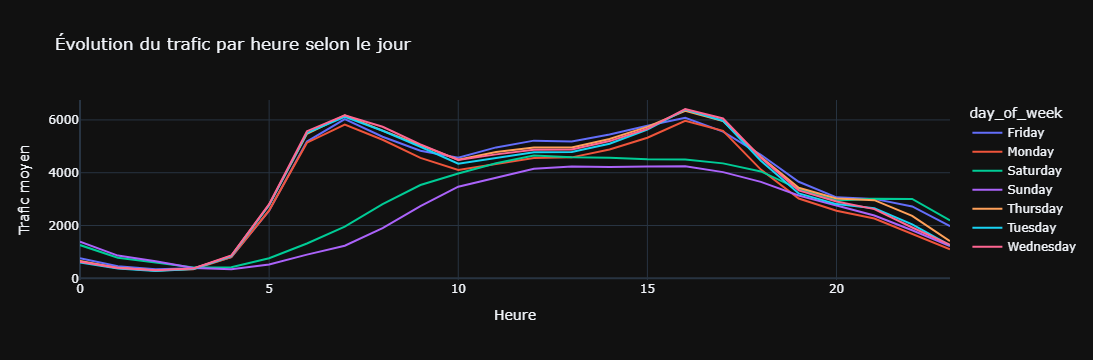

In [14]:
#Visualisation interactive avec Plotly
import plotly.express as px

hourly_day = df.groupby(['hour', 'day_of_week'])['traffic_volume'].mean().reset_index()

fig = px.line(
    hourly_day,
    x='hour',
    y='traffic_volume',
    color='day_of_week',
    title="Évolution du trafic par heure selon le jour",
    labels={'traffic_volume': 'Trafic moyen', 'hour': 'Heure'},
    template='plotly_dark'
)
fig.show()